In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv('datasets/train_merged.csv')

In [4]:
df_raw = df.copy()

In [4]:
print(df.shape)

(307511, 1076)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 1076 entries, SK_ID_CURR to PREV_PRODUCT_COMBINATION_POS others without interest_mean
dtypes: float64(1019), int64(41), str(16)
memory usage: 2.5 GB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,NaN,NaN,NaN,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,NaN,NaN,NaN,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,307511,2,Y,213312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,307511.0,NaN,NaN,NaN,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,NaN,NaN,NaN,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,NaN,NaN,NaN,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,NaN,NaN,NaN,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5


In [6]:
duplicate_count = df.duplicated().sum()

In [7]:
print(duplicate_count)

0


In [8]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [9]:
df["TARGET"].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

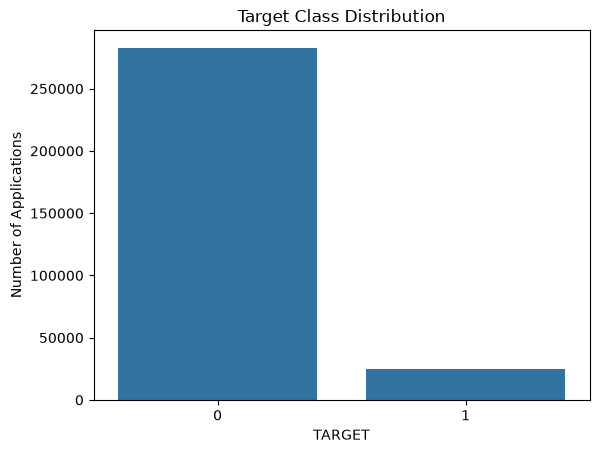

In [10]:
sns.countplot(data=df, x="TARGET")
plt.title("Target Class Distribution")
plt.xlabel("TARGET")
plt.ylabel("Number of Applications")
plt.show()

In [11]:
df.dtypes.value_counts()

float64    1019
int64        41
str          16
Name: count, dtype: int64

In [12]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of numerical columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numerical columns: 1060
Number of categorical columns: 16


/tmp/ipykernel_2572/3579467687.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


In [13]:
print(categorical_cols)

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [14]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100,
    "dtype": df.dtypes
})

missing = missing.sort_values(
    by="missing_percentage",
    ascending=False
)

missing.head(30)

,missing_count,missing_percentage,dtype
PREV_RATE_INTEREST_PRIMARY_min,302902,98.501192,float64
PREV_RATE_INTEREST_PRIVILEGED_mean,302902,98.501192,float64
PREV_RATE_INTEREST_PRIVILEGED_max,302902,98.501192,float64
PREV_RATE_INTEREST_PRIVILEGED_min,302902,98.501192,float64
PREV_RATE_INTEREST_PRIMARY_max,302902,98.501192,float64
PREV_RATE_INTEREST_PRIMARY_mean,302902,98.501192,float64
PREV_CC_AMT_PAYMENT_CURRENT_min_min,254669,82.816224,float64
PREV_CC_AMT_PAYMENT_CURRENT_min_max,254669,82.816224,float64
PREV_CC_AMT_PAYMENT_CURRENT_min_mean,254669,82.816224,float64
PREV_CC_AMT_PAYMENT_CURRENT_max_min,254669,82.816224,float64


In [15]:
missing[missing["missing_count"] > 0].head(50)

,missing_count,missing_percentage,dtype
PREV_RATE_INTEREST_PRIMARY_min,302902,98.501192,float64
PREV_RATE_INTEREST_PRIVILEGED_mean,302902,98.501192,float64
PREV_RATE_INTEREST_PRIVILEGED_max,302902,98.501192,float64
PREV_RATE_INTEREST_PRIVILEGED_min,302902,98.501192,float64
PREV_RATE_INTEREST_PRIMARY_max,302902,98.501192,float64
PREV_RATE_INTEREST_PRIMARY_mean,302902,98.501192,float64
PREV_CC_AMT_PAYMENT_CURRENT_min_min,254669,82.816224,float64
PREV_CC_AMT_PAYMENT_CURRENT_min_max,254669,82.816224,float64
PREV_CC_AMT_PAYMENT_CURRENT_min_mean,254669,82.816224,float64
PREV_CC_AMT_PAYMENT_CURRENT_max_min,254669,82.816224,float64


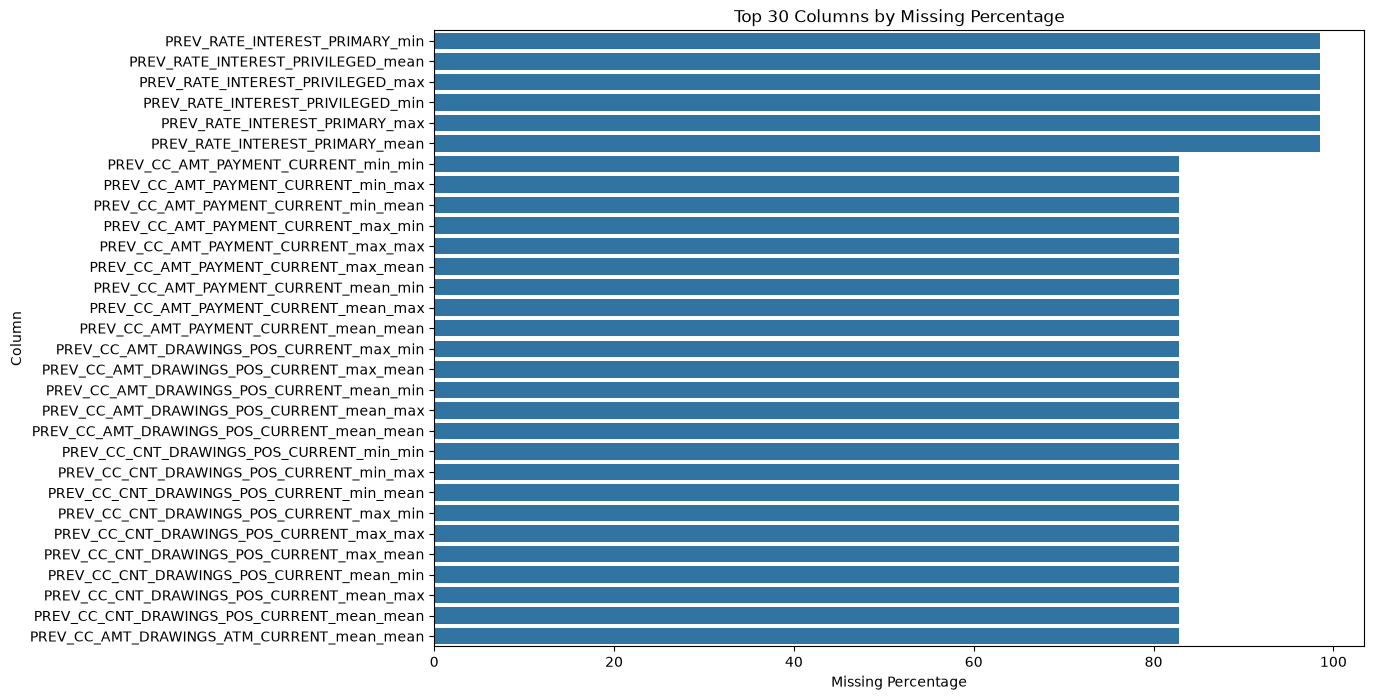

In [16]:
missing_plot = missing[
    missing["missing_count"] > 0
].head(30)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=missing_plot["missing_percentage"],
    y=missing_plot.index
)

plt.title("Top 30 Columns by Missing Percentage")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.show()

In [17]:
def missing_category(x):
    if x == 0:
        return "No missing values"
    elif x < 5:
        return "<5%"
    elif x < 20:
        return "5-20%"
    elif x < 40:
        return "20-40%"
    elif x < 60:
        return "40-60%"
    else:
        return ">60%"

missing["missing_category"] = (
    missing["missing_percentage"]
    .apply(missing_category)
)

missing["missing_category"].value_counts()

missing_category
5-20%                627
>60%                 335
No missing values     55
40-60%                35
20-40%                14
<5%                   10
Name: count, dtype: int64

In [18]:
high_missing = missing[
    missing["missing_percentage"] > 60
]

high_missing

,missing_count,missing_percentage,dtype,missing_category
PREV_RATE_INTEREST_PRIMARY_min,302902,98.501192,float64,>60%
PREV_RATE_INTEREST_PRIVILEGED_mean,302902,98.501192,float64,>60%
PREV_RATE_INTEREST_PRIVILEGED_max,302902,98.501192,float64,>60%
PREV_RATE_INTEREST_PRIVILEGED_min,302902,98.501192,float64,>60%
PREV_RATE_INTEREST_PRIMARY_max,302902,98.501192,float64,>60%
PREV_RATE_INTEREST_PRIMARY_mean,302902,98.501192,float64,>60%
PREV_CC_AMT_PAYMENT_CURRENT_min_min,254669,82.816224,float64,>60%
PREV_CC_AMT_PAYMENT_CURRENT_min_max,254669,82.816224,float64,>60%
PREV_CC_AMT_PAYMENT_CURRENT_min_mean,254669,82.816224,float64,>60%
PREV_CC_AMT_PAYMENT_CURRENT_max_min,254669,82.816224,float64,>60%


In [19]:
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False).head(10))


Column: NAME_CONTRACT_TYPE
Unique values: 2
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

Column: CODE_GENDER
Unique values: 3
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

Column: FLAG_OWN_CAR
Unique values: 2
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

Column: FLAG_OWN_REALTY
Unique values: 2
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

Column: NAME_TYPE_SUITE
Unique values: 8
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               866
Group of people       271
Name: count, dtype: int64

Column: NAME_INCOME_TYPE
Unique values: 8
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                

In [20]:
numeric_summary = df[numeric_cols].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,1.891455e+05,2.782020e+05,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.687979e+05,2.371231e+05,2.565000e+04,1.125000e+05,1.471500e+05,2.025000e+05,1.170000e+08
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,2.700000e+05,5.135310e+05,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,1.652400e+04,2.490300e+04,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,2.385000e+05,4.500000e+05,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,1.000600e-02,1.885000e-02,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-1.968200e+04,-1.575000e+04,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,307511.0,6.381505e+04,1.412758e+05,-1.791200e+04,-2.760000e+03,-1.213000e+03,-2.890000e+02,3.652430e+05


In [21]:
negative_counts = (df[numeric_cols] < 0).sum()

negative_counts[
    negative_counts > 0
].sort_values(ascending=False)

DAYS_BIRTH                                    307511
DAYS_ID_PUBLISH                               307495
DAYS_REGISTRATION                             307431
PREV_DAYS_DECISION_mean                       291057
PREV_DAYS_DECISION_max                        291057
PREV_DAYS_DECISION_min                        291057
PREV_DAYS_DECISION_sum                        291057
PREV_INST_DAYS_INSTALMENT_min_sum             289406
PREV_INST_DAYS_INSTALMENT_min_min             289406
PREV_INST_DAYS_INSTALMENT_min_max             289406
PREV_INST_DAYS_INSTALMENT_min_mean            289406
PREV_INST_DAYS_INSTALMENT_max_sum             289406
PREV_INST_DAYS_INSTALMENT_max_min             289406
PREV_INST_DAYS_INSTALMENT_max_max             289406
PREV_INST_DAYS_INSTALMENT_max_mean            289406
PREV_INST_DAYS_INSTALMENT_mean_sum            289406
PREV_INST_DAYS_INSTALMENT_mean_min            289406
PREV_INST_DAYS_INSTALMENT_mean_max            289406
PREV_INST_DAYS_INSTALMENT_mean_mean           

In [22]:
important_columns = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

df[important_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0


In [23]:
for col in important_columns:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].describe())


AMT_INCOME_TOTAL
count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

AMT_CREDIT
count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

AMT_ANNUITY
count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

AMT_GOODS_PRICE
count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

DAYS_BIRTH
count    307511.000000
mean     -16036.995067
std        4363.988632
min

In [24]:
df["DAYS_EMPLOYED"].value_counts().head(10)

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
-212         150
-229         143
-384         143
-231         140
-215         138
Name: count, dtype: int64

In [25]:
financial_columns = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

for col in financial_columns:
    if col in df.columns:
        print(f"\n{col}")
        print("Zero:", (df[col] == 0).sum())
        print("Negative:", (df[col] < 0).sum())


AMT_INCOME_TOTAL
Zero: 0
Negative: 0

AMT_CREDIT
Zero: 0
Negative: 0

AMT_ANNUITY
Zero: 0
Negative: 0

AMT_GOODS_PRICE
Zero: 0
Negative: 0


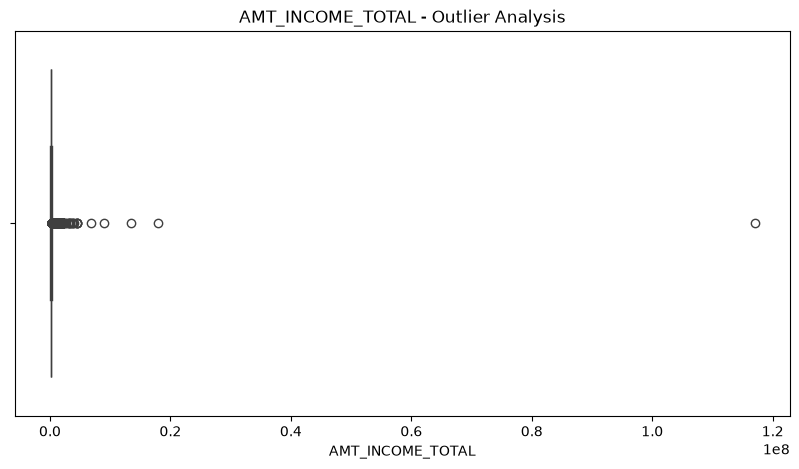

In [26]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["AMT_INCOME_TOTAL"])

plt.title("AMT_INCOME_TOTAL - Outlier Analysis")
plt.show()

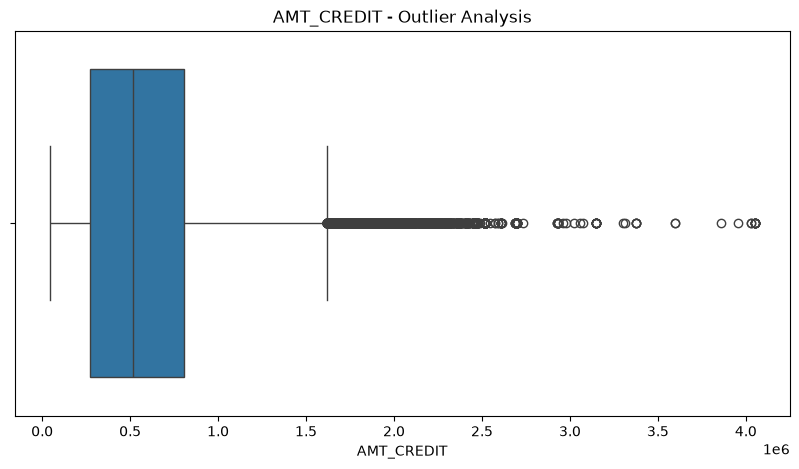

In [27]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["AMT_CREDIT"])

plt.title("AMT_CREDIT - Outlier Analysis")
plt.show()

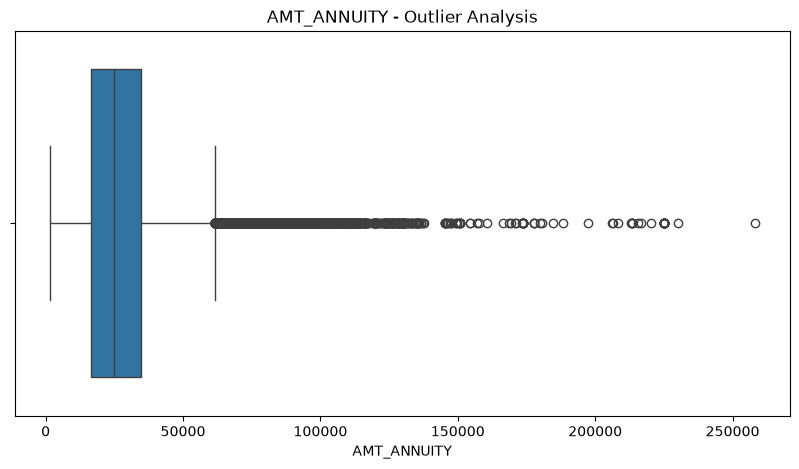

In [28]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["AMT_ANNUITY"])

plt.title("AMT_ANNUITY - Outlier Analysis")
plt.show()